In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import netCDF4
# calculating climatology

count = 1
for year in np.arange(2001,2016):
    for ens in np.arange(1,10):
        print(ens)
        fp ='/Volumes/Expansion/DATA/Reforecast/ECMWF/z/z_'+str(year)+'01_ens'+str(ens).zfill(2)+'.nc'
        nc = netCDF4.Dataset(fp)
        gh = nc['gh'][:]
        if ens == 1 and year ==2001:
            print('ens=1, year=2001')
            gh_clim = gh
        else :
            gh_clim = (gh_clim*(count-1)+gh)/(count)
        count   = count+1



1
ens=1, year=2001
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9
1
2
3
4
5
6
7
8
9


In [18]:
np.shape(gh)

masked_array(data=[1000.,  925.,  850.,  700.,  500.,  300.,  200.,  100.,
                     50.,   10.],
             mask=False,
       fill_value=1e+20)

In [19]:
time   = nc['time'][:]
step   = nc['step'][:]
z      = nc['isobaricInhPa'][:]
latitude    = nc['latitude'][:]
longitude   = nc['longitude'][:]

In [47]:
for ens in np.arange(1,11):
    fp          = '/Volumes/Expansion/DATA/Reforecast/ECMWF/z/z_200101_ens'+str(ens).zfill(2)+'.nc'
    nc          = netCDF4.Dataset(fp)
    gh          = nc['gh'][:]
    time        = nc['time'][:]
    step        = nc['step'][:]
    z           = nc['isobaricInhPa'][:]
    latitude    = nc['latitude'][:]
    longitude   = nc['longitude'][:]

    import os 
    import pandas as pd
    try: ncfile.close()
    except: pass
    os.system('rm /Volumes/Expansion/DATA/Reforecast/ECMWF/z/HW5_ens'+str(ens).zfill(2)+'.nc')
    #!rm '/Volumes/Expansion/DATA/Reforecast/ECMWF/z/test.nc'
    ncfile       = netCDF4.Dataset('/Volumes/Expansion/DATA/Reforecast/ECMWF/z/HW5_ens'+str(ens).zfill(2)+'.nc',mode='w',format='NETCDF4_CLASSIC')
    time_dim     = ncfile.createDimension('time', 8) # unlimited axis (can be appended to).
    step_dim     = ncfile.createDimension('step', 47) # unlimited axis (can be appended to).
    z_dim        = ncfile.createDimension('isobaricInhPa', 10) 
    lat_dim      = ncfile.createDimension('latitude', 121) # latitude axis
    lon_dim      = ncfile.createDimension('longitude', 240) # longitude axis
    for dim in ncfile.dimensions.items():
          print(dim)
    ncfile.title         = 'HW5 data'
    lat                  = ncfile.createVariable('latitude', np.float32, ('latitude',))
    lat.units            = 'degrees_north'
    lat.long_name        = 'latitude'
    lon                  = ncfile.createVariable('longitude', np.float32, ('longitude',))
    lon.units            = 'degrees_east'
    lon.long_name        = 'longitude'
    time_new             = ncfile.createVariable('time', np.float64, ('time',))
    time_new.units       = 'seconds since 1970-01-01'
    time_new.long_name   = 'time'
    step_new             = ncfile.createVariable('step', np.float64, ('step',))
    step_new.units       = 'days since '
    step_new.long_name   = 'step'
    z_new                = ncfile.createVariable('level', np.float64, ('isobaricInhPa',))
    z_new.units          = 'hPa'
    z_new.long_name      = 'isobaricInhPa'

    gh_new               = ncfile.createVariable('gh',np.float64,('time','step','isobaricInhPa','latitude','longitude')) # note: unlimited dimension is leftmost
    gh_new.units         = 'm' # degrees Kelvin
    gh_new.standard_name = 'geopotential height' # this is a CF standard name


    lat[:]              = latitude
    lon[:]              = longitude
    z_new[:]            = z
    time_new[:]         = time
    step_new[:]         = step
    gh_new[:,:,:,:,:]   = (gh - gh_clim)[:,:,0,:,:]
    import datetime as dt
    from netCDF4 import date2num,num2date
    dates1 = pd.date_range('2001-01-01', '2012-01-01', freq='7D')
    dates2 = pd.date_range('2001-01-05', '2012-01-01', freq='7D')
    dates  = dates1.union(dates2)
    dates  = dates[np.where((dates.year==2001)&(dates.month==1))]
    print(dates)
    ncfile.close()


('time', <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 8)
('step', <class 'netCDF4._netCDF4.Dimension'>: name = 'step', size = 47)
('isobaricInhPa', <class 'netCDF4._netCDF4.Dimension'>: name = 'isobaricInhPa', size = 10)
('latitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'latitude', size = 121)
('longitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'longitude', size = 240)
DatetimeIndex(['2001-01-01', '2001-01-05', '2001-01-08', '2001-01-12',
               '2001-01-15', '2001-01-19', '2001-01-22', '2001-01-26',
               '2001-01-29'],
              dtype='datetime64[ns]', freq=None)
('time', <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 8)
('step', <class 'netCDF4._netCDF4.Dimension'>: name = 'step', size = 47)
('isobaricInhPa', <class 'netCDF4._netCDF4.Dimension'>: name = 'isobaricInhPa', size = 10)
('latitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'latitude', size = 121)
('longitude', <class 'netCDF4._netCDF4.Dimension'>: name = 

rm: /Volumes/Expansion/DATA/Reforecast/ECMWF/z/HW5_ens10.nc: No such file or directory


('time', <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 8)
('step', <class 'netCDF4._netCDF4.Dimension'>: name = 'step', size = 47)
('isobaricInhPa', <class 'netCDF4._netCDF4.Dimension'>: name = 'isobaricInhPa', size = 10)
('latitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'latitude', size = 121)
('longitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'longitude', size = 240)
DatetimeIndex(['2001-01-01', '2001-01-05', '2001-01-08', '2001-01-12',
               '2001-01-15', '2001-01-19', '2001-01-22', '2001-01-26',
               '2001-01-29'],
              dtype='datetime64[ns]', freq=None)


In [49]:
for ens in np.arange(1,11):
    fp          = '/Volumes/Expansion/DATA/Reforecast/ECMWF/z/z_200101_ens'+str(ens).zfill(2)+'.nc'
    nc          = netCDF4.Dataset(fp)
    gh          = nc['gh'][:]
    time        = nc['time'][:]
    step        = nc['step'][:]
    z           = nc['isobaricInhPa'][:]
    latitude    = nc['latitude'][:]
    longitude   = nc['longitude'][:]

    import os 
    import pandas as pd
    try: ncfile.close()
    except: pass
    os.system('rm /Volumes/Expansion/DATA/Reforecast/ECMWF/z/HW5_ens'+str(ens).zfill(2)+'.nc')
    #!rm '/Volumes/Expansion/DATA/Reforecast/ECMWF/z/test.nc'
    ncfile       = netCDF4.Dataset('/Volumes/Expansion/DATA/Reforecast/ECMWF/z/HW5_ens'+str(ens).zfill(2)+'.nc',mode='w',format='NETCDF4_CLASSIC')
    time_dim     = ncfile.createDimension('time', 8) # unlimited axis (can be appended to).
    step_dim     = ncfile.createDimension('step', 47) # unlimited axis (can be appended to).
    lat_dim      = ncfile.createDimension('latitude', 121) # latitude axis
    lon_dim      = ncfile.createDimension('longitude', 240) # longitude axis
    for dim in ncfile.dimensions.items():
          print(dim)
    ncfile.title         = 'HW5 data'
    lat                  = ncfile.createVariable('latitude', np.float32, ('latitude',))
    lat.units            = 'degrees_north'
    lat.long_name        = 'latitude'
    lon                  = ncfile.createVariable('longitude', np.float32, ('longitude',))
    lon.units            = 'degrees_east'
    lon.long_name        = 'longitude'
    time_new             = ncfile.createVariable('time', np.float64, ('time',))
    time_new.units       = 'seconds since 1970-01-01'
    time_new.long_name   = 'time'
    step_new             = ncfile.createVariable('step', np.float64, ('step',))
    step_new.units       = 'days since '
    step_new.long_name   = 'step'

    gh_new               = ncfile.createVariable('gh',np.float64,('time','step','latitude','longitude')) # note: unlimited dimension is leftmost
    gh_new.units         = 'm' # degrees Kelvin
    gh_new.standard_name = 'geopotential height' # this is a CF standard name


    lat[:]              = latitude
    lon[:]              = longitude
    time_new[:]         = time
    step_new[:]         = step
    gh_new[:,:,:,:]   = (gh - gh_clim)[:,:,4,:,:]
    import datetime as dt
    from netCDF4 import date2num,num2date
    dates1 = pd.date_range('2001-01-01', '2012-01-01', freq='7D')
    dates2 = pd.date_range('2001-01-05', '2012-01-01', freq='7D')
    dates  = dates1.union(dates2)
    dates  = dates[np.where((dates.year==2001)&(dates.month==1))]
    print(dates)
    ncfile.close()


('time', <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 8)
('step', <class 'netCDF4._netCDF4.Dimension'>: name = 'step', size = 47)
('latitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'latitude', size = 121)
('longitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'longitude', size = 240)
DatetimeIndex(['2001-01-01', '2001-01-05', '2001-01-08', '2001-01-12',
               '2001-01-15', '2001-01-19', '2001-01-22', '2001-01-26',
               '2001-01-29'],
              dtype='datetime64[ns]', freq=None)
('time', <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 8)
('step', <class 'netCDF4._netCDF4.Dimension'>: name = 'step', size = 47)
('latitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'latitude', size = 121)
('longitude', <class 'netCDF4._netCDF4.Dimension'>: name = 'longitude', size = 240)
DatetimeIndex(['2001-01-01', '2001-01-05', '2001-01-08', '2001-01-12',
               '2001-01-15', '2001-01-19', '2001-01-22', '2001-01-26',
               

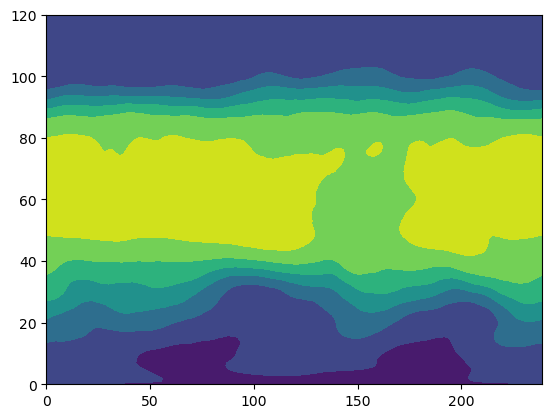

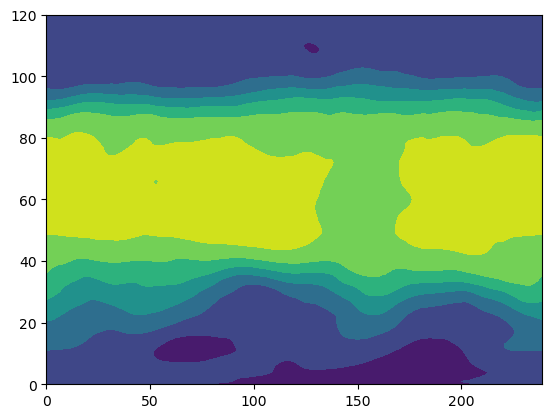

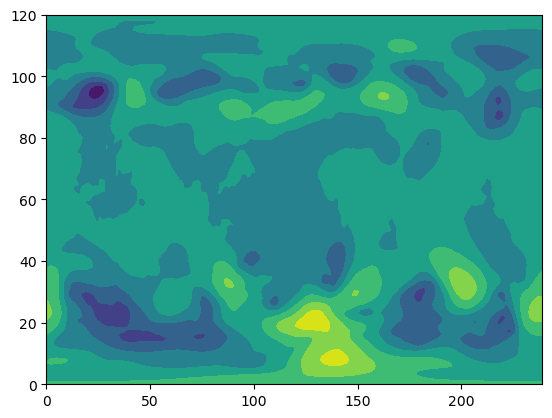

In [45]:
plt.figure()
cs=plt.contourf(gh_clim[0,0,4,:,:])
plt.figure()
cs=plt.contourf(gh_clim[0,1,4,:,:])
plt.figure()
cs=plt.contourf(gh_anomaly[0,1,4,:,:])
